# H SAF ASCAT super-obs vs raw obs on CF0360: aggregation and field of view (FOV)

This notebook shows, for **one analysis window and one small region**, what GEOSldas does with H SAF ASCAT
soil moisture (H121) in its two configurations:

- **Raw obs** (`superob_grid_deg = 0`): every QC-passing H121 obs is assigned to a tile, and all obs that land
  in the same tile are averaged into **one obs per tile** (per satellite).
- **Super-obs** (`superob_grid_deg = 0.25`): the QC-passing obs are first averaged on a regular **0.25° lat/lon
  grid**, and each grid cell's average becomes one obs, placed at the **mean location** of its raw obs.

The two configurations also use **different fields of view (FOV)** when the model predicts the obs
(`get_obs_pred` in `clsm_ensupd_upd_routines.F90`). That is the main thing to look at here, since the FOV
decides which tiles each obs "sees":

| | Raw obs | Super-obs |
|---|---|---|
| obs position | mean of the raw obs in one **tile** | mean of the raw obs in one **0.25° cell** |
| `FOV`, `FOV_units` | 12.5, `'km'` | 0.1410, `'deg'` (= 0.25/√π, so the circle has the cell's area) |
| tiles in the FOV | tile centre of mass within an ellipse of radius **2 × FOV = 25 km** (lon radius stretched by 1/cos(lat), i.e. a circle in km) | tile centre of mass within a **circle of radius 0.141° in degrees** (an ellipse in km, narrower east-west, like the cell itself) |
| tile weights | **Gaussian** `exp(-½ (d / 12.5 km)²)` × tile area | **uniform** × tile area |
| model prediction | Σ w·SFMC / Σ w over the tiles in the FOV | same |

So going from raw obs to super-obs changes three things at once: **how many obs** there are, **how big** each
footprint is, and the **shape of the weighting**.

**Case.** Analysis time 2019-05-01 03z (the first cycle, so both runs start from the same restarts), and a
2° × 2.5° box in south-west Kansas, which had a full overpass from all three Metops in this window. Runs:

- raw obs: `M21C_test_CF0360_baseline_HSAF_xc03125`
- super-obs: `M21C_test_CF0360_superob025ml_OL6sc_HSAF_xc03125` (0.25°, mean location)

Both assimilate H SAF only (species 56–58, file index 12–14 = Metop-A/B/C) with `xcorr = 0.3125°`.

**How we know the pictures are right.** Everything is recomputed in Python from the H121 files, and each step
is checked against what GEOSldas wrote:

1. QC'd obs counts per H121 file vs the `ldas_log` (section 3),
2. obs positions and tile numbers vs ObsFcstAna, for both modes (section 5),
3. the FOV-weighted model prediction vs ObsFcstAna `fcst`, for both modes (section 6).

The code facts in this notebook were read from `@GEOSldas_GridComp` on `feature/amfox/hsaf-superobs` (e9c365d):
`read_obs_sm_ASCAT_HSAF` and `get_tile_num_for_obs` (`clsm_ensupd_read_obs.F90`), `get_obs_pred`
(`clsm_ensupd_upd_routines.F90`), and `get_tile_num_from_latlon`, `get_tile_num_in_ellipse`
(`LDAS_TileCoordRoutines.F90`).

Run on Discover with GEOSpyD Python 3.13 (`/usr/local/other/GEOSpyD/25.3.1-0/2025-10-07/envs/py3.13`).
Takes about a minute; no cache needed.

## 1. Imports, paths and settings

In [1]:
import glob
import re
import sys
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse, Rectangle

%matplotlib inline

def find_repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / '.git').exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd())

# GEOSldas' own python readers (tilecoord, obsparam)
sys.path.insert(0, '/discover/nobackup/projects/land_da/GEOSldas_develop/GEOSldas/src/Components/'
                   '@GEOSldas_GridComp/GEOSldas_App/util/shared/python')
import read_GEOSldas as rg

ROOT = Path('/gpfsm/dnb06/projects/p284/M21C_testing')
RUNS = {'raw':     'M21C_test_CF0360_baseline_HSAF_xc03125',
        'superob': 'M21C_test_CF0360_superob025ml_OL6sc_HSAF_xc03125'}
OUT_SUB = 'output/CF0360x6C_GLOBAL'

# BCS v14 rasters (30 arc-seconds) to draw the true tile shapes, as in cf0360_grid_and_tiles.ipynb
BCS_GEOM = Path('/discover/nobackup/projects/gmao/bcs_shared/fvInput/ExtData/esm/tiles/v14/geometry/CF0360x6C_CF0360x6C')
RASTERS = {'cell': BCS_GEOM / 'rst' / 'CF0360x6C.rst',
           'tile': BCS_GEOM / 'rst' / 'CF0360x6C_CF0360x6C-Pfafstetter.rst'}

H121 = Path('/discover/nobackup/projects/land_da/ASCAT_SSM_CDR/H121')
SATS = ['metop_a', 'metop_b', 'metop_c']
SAT_LABEL = {'metop_a': 'Metop-A', 'metop_b': 'Metop-B', 'metop_c': 'Metop-C'}
SAT_COLOR = {'metop_a': 'tab:blue', 'metop_b': 'tab:orange', 'metop_c': 'tab:green'}

ANA_TIME = dt.datetime(2019, 5, 1, 3)      # analysis time; window = (ANA_TIME - 1.5 h, ANA_TIME + 1.5 h]
DT_ASSIM = dt.timedelta(hours=3)

REGION = (36.5, 38.5, -100.5, -98.0)      # lat0, lat1, lon0, lon1: south-west Kansas
ZOOM   = (37.25, 37.95, -99.55, -98.70)   # a smaller box inside REGION for the detailed panels
MARGIN = 0.6                              # [deg] read obs/tiles this far outside REGION (FOVs reach ~0.3 deg)

FIG_DIR = REPO_ROOT / 'projects' / 'M21C_land' / 'figures' / 'superob_fov'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MAPL_RADIUS_KM = 6371.0                   # MAPL_RADIUS / 1000, used by dist_km2deg
KM2DEG = (180.0 / np.pi) / MAPL_RADIUS_KM  # [deg per km] in latitude
FAC_SEARCH_FOV_KM = 2.0                   # get_obs_pred: search radius = 2 * FOV when FOV_units = 'km'
N_LAND = 1188020                          # land tiles (typ 100) come first in the tile table

### 1a. Obs parameters as the runs saw them

The FOV, FOV units, obs-error correlation length and forecast variable are taken from each run's `rc_out`
obsparam file, not typed in. H SAF is read as `sfds` (degree of saturation) but is scaled to the model
climatology, and the model side (`fcstvarname`) is **SFMC**, so the obs prediction is a weighted average of
tile SFMC. The super-ob grid spacing is not in the obsparam file, so it is read from the run's `ldas_log`.

In [2]:
def run_file(run, sub, pattern):
    files = sorted(glob.glob(str(ROOT / RUNS[run] / OUT_SUB / sub / pattern)))
    assert files, f'nothing matches {sub}/{pattern} for {run}'
    return files[0]

LOG = {run: Path(run_file(run, 'rc_out/Y2019/M05', '*ldas_log.20190501_0000z.txt')).read_text() for run in RUNS}

OP = {}
for run in RUNS:
    op = rg.read_obs_param(run_file(run, 'rc_out/Y2019/M05', '*ldas_obsparam.20190501_0000z.txt'))
    for k, o in enumerate(op, start=1):              # k = species index used in ObsFcstAna
        for sat in SATS:
            if o['descr'].strip("'") == f'ASCAT_HSAF_MET{sat[-1].upper()}_SM':
                OP[run, sat] = dict(ofa_species=k, FOV=o['FOV'], FOV_units=o['FOV_units'].strip("'"),
                                    xcorr=o['xcorr'], ycorr=o['ycorr'], errstd=o['errstd'],
                                    varname=o['varname'].strip("'"), fcstvarname=o['fcstvarname'].strip("'"))
m = re.search(r'superob_grid_deg =\s*([0-9.]+)', LOG['superob'])
SUPEROB_GRID = float(m.group(1))
assert not re.search(r'superob_grid_deg =', LOG['raw']), 'the raw run should not super-ob'

print(pd.DataFrame(OP).T.to_string())
print(f'\nsuper-ob grid spacing (from ldas_log): {SUPEROB_GRID} deg; '
      f'0.25/sqrt(pi) = {SUPEROB_GRID / np.sqrt(np.pi):.4f} deg')

FOV = {run: (OP[run, 'metop_a']['FOV'], OP[run, 'metop_a']['FOV_units']) for run in RUNS}
for run in RUNS:
    assert all((OP[run, s]['FOV'], OP[run, s]['FOV_units']) == FOV[run] for s in SATS)
XCORR = OP['raw', 'metop_a']['xcorr']
SPECIES_TO_SAT = {OP['raw', s]['ofa_species']: s for s in SATS}
assert SPECIES_TO_SAT == {OP['superob', s]['ofa_species']: s for s in SATS}

Reading /gpfsm/dnb06/projects/p284/M21C_testing/M21C_test_CF0360_baseline_HSAF_xc03125/output/CF0360x6C_GLOBAL/rc_out/Y2019/M05/M21C_test_CF0360_baseline_HSAF_xc03125.ldas_obsparam.20190501_0000z.txt
Done reading obs_param for 14 species
Reading /gpfsm/dnb06/projects/p284/M21C_testing/M21C_test_CF0360_superob025ml_OL6sc_HSAF_xc03125/output/CF0360x6C_GLOBAL/rc_out/Y2019/M05/M21C_test_CF0360_superob025ml_OL6sc_HSAF_xc03125.ldas_obsparam.20190501_0000z.txt
Done reading obs_param for 14 species
                ofa_species    FOV FOV_units   xcorr   ycorr errstd varname fcstvarname
raw     metop_a          12   12.5        km  0.3125  0.3125    9.0    sfds        sfmc
        metop_b          13   12.5        km  0.3125  0.3125    9.0    sfds        sfmc
        metop_c          14   12.5        km  0.3125  0.3125    9.0    sfds        sfmc
superob metop_a          12  0.141       deg  0.3125  0.3125    9.0    sfds        sfmc
        metop_b          13  0.141       deg  0.3125  0.3125    

## 2. Tiles

`ldas_tilecoord.bin` is the tile table the model used (centre of mass `com_lon/com_lat`, bounding box, area).
Only the first `N_LAND` tiles are land tiles; obs are matched to land tiles only (the reader's `N_catd`).
Both runs use the same tile table.

In [3]:
TC = {run: rg.read_tilecoord(run_file(run, 'rc_out', '*ldas_tilecoord.bin')) for run in RUNS}
for k in ['com_lon', 'com_lat', 'min_lon', 'max_lon', 'min_lat', 'max_lat', 'area']:
    assert np.array_equal(TC['raw'][k], TC['superob'][k])
tc = TC['raw']
assert (tc['typ'][:N_LAND] == 100).all() and (tc['typ'][N_LAND:] != 100).all()

# Fortran works in single precision; keep the tile coordinates as float32 so near-ties resolve the same way
COM_LON = tc['com_lon'][:N_LAND].astype(np.float32)
COM_LAT = tc['com_lat'][:N_LAND].astype(np.float32)
BBOX = {k: tc[k][:N_LAND].astype(np.float32) for k in ['min_lon', 'max_lon', 'min_lat', 'max_lat']}
AREA = tc['area'][:N_LAND].astype(np.float64)        # only relative areas matter (weights are normalised)

NY, NX, RES = 21600, 43200, 1.0 / 120.0

def read_raster(name, lat0, lat1, lon0, lon1):
    # Window of a 30-arcsec BCS raster: (values [rows S->N, cols W->E], lat_edges, lon_edges)
    mm = np.memmap(RASTERS[name], dtype='<i4', mode='r').reshape(NY, NX + 2)
    r0, r1 = int(np.floor((lat0 + 90) / RES)), int(np.ceil((lat1 + 90) / RES))
    c0, c1 = int(np.floor((lon0 + 180) / RES)), int(np.ceil((lon1 + 180) / RES))
    vals = np.array(mm[r0:r1, c0 + 1:c1 + 1])             # +1 skips the Fortran record marker
    return vals, -90 + RES * np.arange(r0, r1 + 1), -180 + RES * np.arange(c0, c1 + 1)

def boundaries(a):
    # True on pixels whose id differs from the pixel to the east or north
    e = np.zeros(a.shape, bool)
    e[:, 1:] |= a[:, 1:] != a[:, :-1]
    e[1:, :] |= a[1:, :] != a[:-1, :]
    return e

print(f'{tc["N_tile"]:,} tiles, of which {N_LAND:,} land')

reading from /gpfsm/dnb06/projects/p284/M21C_testing/M21C_test_CF0360_baseline_HSAF_xc03125/output/CF0360x6C_GLOBAL/rc_out/M21C_test_CF0360_baseline_HSAF_xc03125.ldas_tilecoord.bin


done reading file
reading from /gpfsm/dnb06/projects/p284/M21C_testing/M21C_test_CF0360_superob025ml_OL6sc_HSAF_xc03125/output/CF0360x6C_GLOBAL/rc_out/M21C_test_CF0360_superob025ml_OL6sc_HSAF_xc03125.ldas_tilecoord.bin


done reading file
1,274,555 tiles, of which 1,188,020 land


## 3. Raw H121 obs in the window, with the reader's QC

`read_obs_sm_ASCAT_HSAF` reads the hourly H121 files whose sensing start is in the window (extended back by
one hour), keeps obs in the half-open window (low, up], and applies the QC: SSM valid (0–100 %), not open water
(`surface_flag` bit 1), model and sigma0 usable (`processing_flag` bits 1+2), backscatter not noisy
(`backscatter40_flag` bit 4), wetland fraction and topographic complexity known and < 10 %, subsurface-scattering
probability < 5 % (fill accepted), SSM sensitivity > 1 dB.

**Window timing detail.** To reproduce the reader's counts exactly, the window must be shifted **64.184 s later**
than (01:30, 04:30] UTC. The reader converts the obs time (Unix days) to J2000 seconds with
`unix_to_J2000_s = 10957.5·86400 + 64.184` (i.e. it adds the TT−UTC offset), while the window bounds come from
`datetime_to_J2000seconds`, apparently without that offset. Effect: the window is (01:31:04, 04:31:04] UTC.
That is a ~1-minute edge effect, harmless for DA, but it is why a naive window gives slightly different counts.
(This is inferred from the counts; `datetime_to_J2000seconds` itself was not read.)

In [4]:
TT_MINUS_UTC = 64.184
UNIX0 = dt.datetime(1970, 1, 1)
W_LOW = (ANA_TIME - DT_ASSIM / 2 - UNIX0).total_seconds() + TT_MINUS_UTC
W_UP = W_LOW + DT_ASSIM.total_seconds()

def window_files(sat):
    # the reader keeps files with sensing start in (low - 1 h, up]; H121 files are hourly
    files = []
    for f in sorted((H121 / sat / f'Y{ANA_TIME:%Y}' / f'M{ANA_TIME:%m}').glob('*.nc')):
        start = dt.datetime.strptime(f.name.split('_')[-6], '%Y%m%d%H%M%S')
        if ANA_TIME - DT_ASSIM / 2 - dt.timedelta(hours=1) < start <= ANA_TIME + DT_ASSIM / 2:
            files.append(f)
    return files

def read_h121(f, sat):
    with nc.Dataset(f) as d:
        d.set_auto_maskandscale(False)                       # raw packed values, as the Fortran reads them
        v = {k: d[k][:] for k in ['latitude', 'longitude', 'time', 'surface_soil_moisture', 'surface_flag',
                                  'processing_flag', 'backscatter40_flag', 'wetland_fraction',
                                  'topographic_complexity', 'subsurface_scattering_probability',
                                  'surface_soil_moisture_sensitivity']}
    s8 = lambda a: a.astype(np.int8).astype(np.int32)       # NC_BYTE probabilities; fill = -128
    ssm = v['surface_soil_moisture'].astype(np.int32)
    t = v['time'] * 86400.0                                  # days since 1970 -> s
    ok = ((ssm >= 0) & (ssm <= 10000) & (t > W_LOW) & (t <= W_UP)
          & ((v['surface_flag'] & 1) == 0) & ((v['processing_flag'] & 3) == 0)
          & ((v['backscatter40_flag'] & 4) == 0)
          & (s8(v['wetland_fraction']) >= 0) & (s8(v['wetland_fraction']) < 10)
          & (s8(v['topographic_complexity']) >= 0) & (s8(v['topographic_complexity']) < 10)
          & (s8(v['subsurface_scattering_probability']) < 5)
          & (v['surface_soil_moisture_sensitivity'] * 1e-7 > 1.0))
    return pd.DataFrame({'sat': sat,
                         'lat': v['latitude'][ok].astype(np.float32) * np.float32(1e-6),   # real * real, as in Fortran
                         'lon': v['longitude'][ok].astype(np.float32) * np.float32(1e-6),
                         'sm': (ssm[ok] * 0.01 / 100).astype(np.float32),      # % -> fraction
                         'time': t[ok]})

# per-file counts written by the reader, first occurrence of each file in the log (= the 03z window)
log_counts = {}
for fname, n in re.findall(r'Reading H SAF ASCAT SM data from file: (\S+)\s+read_obs_sm_ASCAT_HSAF:\s+(\d+)\s+obs passed QC',
                           LOG['superob']):
    log_counts.setdefault(Path(fname).name, int(n))

frames, check = [], []
for sat in SATS:
    for f in window_files(sat):
        df = read_h121(f, sat)
        frames.append(df)
        check.append({'sat': sat, 'file hour': f.name.split('_')[-6][8:10] + 'z', 'python QC': len(df),
                      'ldas_log': log_counts.get(f.name)})
RAW_ALL = pd.concat(frames, ignore_index=True)
check = pd.DataFrame(check)
print(check.to_string(index=False))
assert (check['python QC'] == check['ldas_log']).all(), 'QC re-implementation does not match the reader'
print(f'\nall {len(check)} files match; {len(RAW_ALL):,} QC-passing obs globally in the window')

    sat file hour  python QC  ldas_log
metop_a       01z       4453      4453
metop_a       02z      27808     27808
metop_a       03z      22798     22798
metop_a       04z       8112      8112
metop_b       01z      15205     15205
metop_b       02z      47194     47194
metop_b       03z      13193     13193
metop_b       04z      30201     30201
metop_c       01z      15532     15532
metop_c       02z      24828     24828
metop_c       04z          0         0
metop_c       03z      47174     47174

all 12 files match; 256,498 QC-passing obs globally in the window


## 4. From raw obs to the obs that GEOSldas assimilates

**Obs-to-tile rule** (`get_tile_num_for_obs` → `get_tile_num_from_latlon`). Tiles are listed under the cell of
the lat/lon *pert grid* (1440 × 1080 = 0.25° × 1/6° for C360) holding their centre of mass. An obs goes to the
land tile in its pert cell whose centre of mass is nearest (|Δlon| + |Δlat| in degrees). It is **dropped** if it
lies outside that tile's bounding box **and** farther than the FOV from the tile's centre of mass, in lon or
in lat. (For `FOV_units = 'km'` the FOV is converted to degrees with `dist_km2deg`, so the raw run allows
12.5 km; the super-ob run allows 0.141°.)

- **Raw mode:** each raw obs gets a tile; all obs of one satellite in the same tile are averaged (value, lat,
  lon, time). The obs position written to ObsFcstAna is the **mean position of the raw obs in that tile**.
- **Super-ob mode:** raw obs are binned by `i = int((lon+180)/0.25)+1`, `j = int((lat+90)/0.25)+1`, averaged
  per cell (value, lat, lon, time), and the cell's **mean location** is matched to a tile with the same rule.
  If two cells pick the same tile (a "collision"), the cell whose mean location is nearer the tile's centre of
  mass (Euclidean, in degrees) wins; ties go to the cell visited first (`j` outer, `i` inner loop).

The super-ob step is applied **globally** below, so its summary can be compared with the reader's log.

In [5]:
NLON_P, NLAT_P = 1440, 1080
DLON_P, DLAT_P = np.float32(360 / NLON_P), np.float32(180 / NLAT_P)

def pert_cell(lat, lon):
    # flat pert-grid cell index, as get_ij_ind_from_latlon: ceiling((x - ll)/dx) in single precision
    i = np.ceil((np.asarray(lon, np.float32) - np.float32(-180)) / DLON_P).astype(np.int64)
    j = np.ceil((np.asarray(lat, np.float32) - np.float32(-90)) / DLAT_P).astype(np.int64)
    return np.clip(j, 1, NLAT_P) * NLON_P + np.clip(i, 1, NLON_P)

_key = pert_cell(COM_LAT, COM_LON)
_order = np.argsort(_key, kind='stable')
_sorted_key = _key[_order]

def max_dist_deg(lat, fov, units):
    # (max_dist_x, max_dist_y) in degrees, as in get_tile_num_for_obs
    if units == 'deg':
        return np.full(len(lat), fov, np.float32), np.float32(fov)
    dy = np.float32(fov * KM2DEG)
    return (dy / np.cos(np.radians(lat))).astype(np.float32), dy

def assign_tiles(lat, lon, fov, units):
    # 1-based land tile number per obs; -1 = no land tile in the pert cell, -2 = dropped (outside bbox and too far)
    lat = np.asarray(lat, np.float32)
    lon = np.asarray(lon, np.float32)
    mdx, mdy = max_dist_deg(lat, fov, units)
    k = pert_cell(lat, lon)
    a, b = np.searchsorted(_sorted_key, k), np.searchsorted(_sorted_key, k, side='right')
    out = np.full(len(lat), -1, np.int64)
    for n in range(len(lat)):
        cand = _order[a[n]:b[n]]
        if cand.size == 0:
            continue
        dx, dy = np.abs(lon[n] - COM_LON[cand]), np.abs(lat[n] - COM_LAT[cand])
        best = np.argmin(dx + dy)                              # first minimum, like the Fortran strict '<'
        t = cand[best]
        outside = (lon[n] < BBOX['min_lon'][t] or lon[n] > BBOX['max_lon'][t] or
                   lat[n] < BBOX['min_lat'][t] or lat[n] > BBOX['max_lat'][t])
        too_far = dx[best] > mdx[n] or dy[best] > mdy
        out[n] = -2 if (outside and too_far) else t + 1
    return out

# ---- raw mode: obs near the region only (the raw run is not super-obbed, so no global summary to check)
lat0, lat1, lon0, lon1 = REGION
RAW = RAW_ALL[RAW_ALL.lat.between(lat0 - MARGIN, lat1 + MARGIN) &
              RAW_ALL.lon.between(lon0 - MARGIN, lon1 + MARGIN)].copy()
RAW['tile'] = assign_tiles(RAW.lat, RAW.lon, *FOV['raw'])
RAWMODE = (RAW[RAW.tile > 0].groupby(['sat', 'tile'])
           .agg(lat=('lat', 'mean'), lon=('lon', 'mean'), sm=('sm', 'mean'), n_raw=('sm', 'size'))
           .reset_index())

# ---- super-ob mode: global, so that the summary can be checked against the log
def superobs(raw, grid):
    r = raw.copy()
    n_lon, n_lat = int(round(360 / grid)), int(round(180 / grid))
    lon = np.mod(r.lon.astype(np.float64) + 180.0, 360.0) - 180.0
    r['i'] = np.minimum(n_lon, ((lon + 180.0) / grid).astype(int) + 1)
    r['j'] = np.minimum(n_lat, ((r.lat.astype(np.float64) + 90.0) / grid).astype(int) + 1)
    r['lon_n'] = lon
    so = (r.groupby(['sat', 'j', 'i'])                        # sorted j outer, i inner = Fortran loop order
          .agg(lat=('lat', lambda x: np.mean(x.astype(np.float64))),
               lon=('lon_n', 'mean'), sm=('sm', 'mean'), n_raw=('sm', 'size'))
          .reset_index())
    so[['lat', 'lon']] = so[['lat', 'lon']].astype(np.float32)
    so['cell_lat0'] = -90 + (so.j - 1) * grid
    so['cell_lon0'] = -180 + (so.i - 1) * grid
    return so

SO_ALL = superobs(RAW_ALL, SUPEROB_GRID)
SO_ALL['tile'] = assign_tiles(SO_ALL.lat, SO_ALL.lon, *FOV['superob'])

# collisions: loop over cells in the reader's order (j outer, i inner); a cell takes a tile if the tile is
# still free or if it is nearer to the tile's centre of mass than the current holder (best_dist2 is real*4)
t0 = np.clip(SO_ALL.tile.to_numpy() - 1, 0, None)
dlon = np.abs(SO_ALL.lon.to_numpy(np.float64) - COM_LON[t0].astype(np.float64))
dlon = np.minimum(dlon, 360 - dlon)
dist2 = dlon**2 + (SO_ALL.lat.to_numpy(np.float64) - COM_LAT[t0].astype(np.float64))**2
holder = {}
for n, (sat, t, d2) in enumerate(zip(SO_ALL.sat.to_numpy(), SO_ALL.tile.to_numpy(), dist2)):
    if t <= 0:
        continue
    h = holder.get((sat, t))
    if h is None or d2 < np.float64(np.float32(h[1])):
        holder[sat, t] = (n, d2)
SO_ALL['emitted'] = False
SO_ALL.loc[SO_ALL.index[[n for n, _ in holder.values()]], 'emitted'] = True

summary = []
for sat in SATS:
    s = SO_ALL[SO_ALL.sat == sat]
    n_tile = (s.tile > 0).sum()
    summary.append({'sat': sat, 'raw obs passing QC': (RAW_ALL.sat == sat).sum(), 'occupied super-ob cells': len(s),
                    'cells without a tile': (s.tile <= 0).sum(),
                    'tile collisions': n_tile - s[s.tile > 0].tile.nunique(), 'emitted super-obs': s.emitted.sum()})
summary = pd.DataFrame(summary).set_index('sat')

# the same numbers from the reader's log (first three super-ob summaries = the 03z window, Metop-A/B/C)
pat = (r'raw obs passing QC\s*=\s*(\d+).*?occupied super-ob cells\s*=\s*(\d+).*?cells without a tile\s*=\s*(\d+)'
       r'.*?tile collisions\s*=\s*(\d+).*?emitted super-obs\s*=\s*(\d+)')
log_sum = pd.DataFrame([list(map(int, g)) for g in re.findall(pat, LOG['superob'], re.S)[:3]],
                       index=SATS, columns=summary.columns)
print('python:'); print(summary.to_string())
print('\nldas_log:'); print(log_sum.to_string())
print('\nidentical:', summary.equals(log_sum))

SO = SO_ALL[SO_ALL.emitted & SO_ALL.lat.between(lat0 - MARGIN, lat1 + MARGIN) &
            SO_ALL.lon.between(lon0 - MARGIN, lon1 + MARGIN)].copy()

python:
         raw obs passing QC  occupied super-ob cells  cells without a tile  tile collisions  emitted super-obs
sat                                                                                                           
metop_a               63171                    24863                  1191               48              23624
metop_b              105793                    39015                  2038               73              36904
metop_c               87534                    33627                  1777               64              31786

ldas_log:
         raw obs passing QC  occupied super-ob cells  cells without a tile  tile collisions  emitted super-obs
metop_a               63171                    24863                  1191               48              23624
metop_b              105793                    39015                  2038               73              36904
metop_c               87534                    33627                  1777               64  

### 4a. The region: raw obs, raw-mode obs and super-obs

Shown for **Metop-A only** (see 4b for why the other two look the same). Grey lines are tile boundaries, black
lines are CF0360 grid cells, dashed lines are the 0.25° super-ob grid. Colours give the number of raw obs
averaged into each obs.

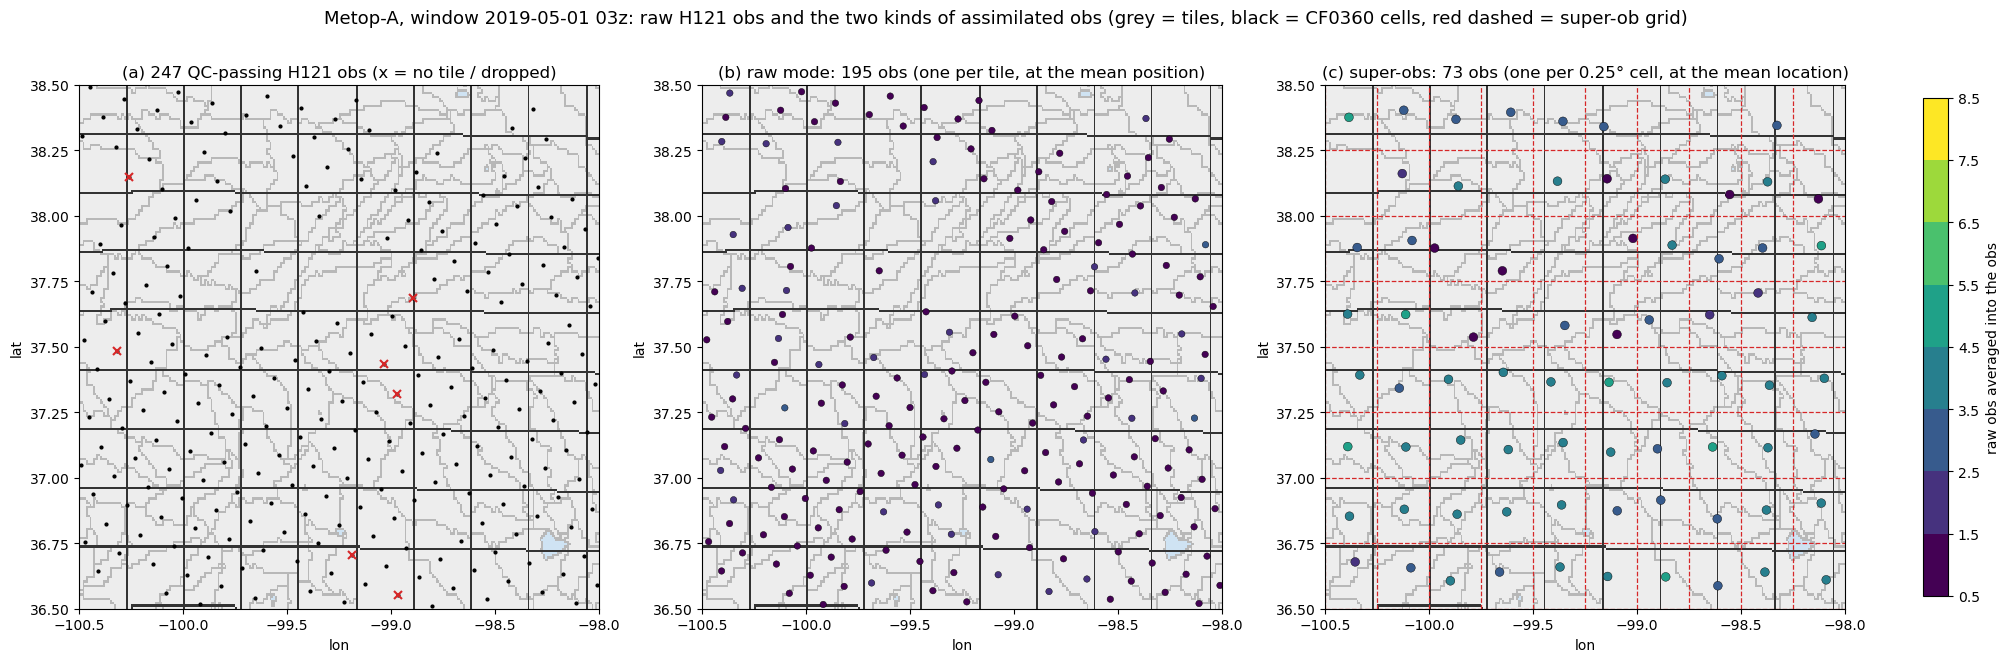

         raw QC obs  raw-mode obs  super-obs  raw obs per raw-mode obs  raw obs per super-ob
metop_a         247           195         73                      1.23                  3.37
metop_b         155           125         49                      1.20                  3.16
metop_c         247           195         73                      1.23                  3.37


In [6]:
SHOW_SAT = 'metop_a'

def inbox(df, box):
    a, b, c, d = box
    return df[df.lat.between(a, b) & df.lon.between(c, d)]

def tile_background(ax, box, land_shade='0.93'):
    a, b, c, d = box
    tile, lat_e, lon_e = read_raster('tile', a, b, c, d)
    cell, _, _ = read_raster('cell', a, b, c, d)
    land = tile <= N_LAND
    ax.pcolormesh(lon_e, lat_e, np.where(land, 0, 1), cmap=mcolors.ListedColormap([land_shade, '#cfe3f3']),
                  vmin=-0.5, vmax=1.5, rasterized=True)
    for mask, color in [(boundaries(np.where(land, tile, -1)), '0.72'), (boundaries(cell), '0.2')]:
        ax.pcolormesh(lon_e, lat_e, np.ma.masked_where(~mask, mask.astype(float)),
                      cmap=mcolors.ListedColormap([color]), vmin=0, vmax=1, rasterized=True)
    return tile, lat_e, lon_e

def superob_grid_lines(ax, box, **kw):
    a, b, c, d = box
    for x in np.arange(np.ceil(c / SUPEROB_GRID) * SUPEROB_GRID, d, SUPEROB_GRID):
        ax.axvline(x, **kw)
    for y in np.arange(np.ceil(a / SUPEROB_GRID) * SUPEROB_GRID, b, SUPEROB_GRID):
        ax.axhline(y, **kw)

def finish(ax, box):
    a, b, c, d = box
    ax.set_xlim(c, d); ax.set_ylim(a, b)
    ax.set_aspect(1 / np.cos(np.radians(0.5 * (a + b))))    # true shape in km
    ax.set_xlabel('lon'); ax.set_ylabel('lat')

raw_r = inbox(RAW[RAW.sat == SHOW_SAT], REGION)
rawmode_r = inbox(RAWMODE[RAWMODE.sat == SHOW_SAT], REGION)
so_r = inbox(SO[SO.sat == SHOW_SAT], REGION)
ncol = mcolors.BoundaryNorm(np.arange(0.5, 9.5), 256)
cmap_n = plt.get_cmap('viridis')

fig, axs = plt.subplots(1, 3, figsize=(20, 6.6), constrained_layout=True)
for ax in axs:
    tile_background(ax, REGION)
superob_grid_lines(axs[2], REGION, color='tab:red', ls='--', lw=0.9)
axs[0].plot(raw_r.lon, raw_r.lat, '.', color='k', ms=4)
axs[0].plot(raw_r.lon[raw_r.tile < 0], raw_r.lat[raw_r.tile < 0], 'x', color='tab:red', ms=6, mew=1.5)
sc = axs[1].scatter(rawmode_r.lon, rawmode_r.lat, c=rawmode_r.n_raw, cmap=cmap_n, norm=ncol, s=22, edgecolor='k', lw=0.3)
axs[2].scatter(so_r.lon, so_r.lat, c=so_r.n_raw, cmap=cmap_n, norm=ncol, s=40, edgecolor='k', lw=0.3)
axs[0].set_title(f'(a) {len(raw_r)} QC-passing H121 obs (x = no tile / dropped)')
axs[1].set_title(f'(b) raw mode: {len(rawmode_r)} obs (one per tile, at the mean position)')
axs[2].set_title(f'(c) super-obs: {len(so_r)} obs (one per 0.25° cell, at the mean location)')
for ax in axs:
    finish(ax, REGION)
fig.colorbar(sc, ax=axs[1:], shrink=0.8, label='raw obs averaged into the obs')
fig.suptitle(f'{SAT_LABEL[SHOW_SAT]}, window {ANA_TIME:%Y-%m-%d %H}z: raw H121 obs and the two kinds of '
             f'assimilated obs (grey = tiles, black = CF0360 cells, red dashed = super-ob grid)', fontsize=13)
fig.savefig(FIG_DIR / 'region_raw_rawmode_superob.png', dpi=150)
plt.show()

stats = pd.DataFrame({
    'raw QC obs': [len(inbox(RAW[RAW.sat == s], REGION)) for s in SATS],
    'raw-mode obs': [len(inbox(RAWMODE[RAWMODE.sat == s], REGION)) for s in SATS],
    'super-obs': [len(inbox(SO[SO.sat == s], REGION)) for s in SATS],
    'raw obs per raw-mode obs': [inbox(RAWMODE[RAWMODE.sat == s], REGION).n_raw.mean() for s in SATS],
    'raw obs per super-ob': [inbox(SO[SO.sat == s], REGION).n_raw.mean() for s in SATS]}, index=SATS)
print(stats.round(2).to_string())

### 4b. The three Metops observe the same H121 grid points

H121 is a fixed grid (12.5 km spacing), and Metop-A/B/C fly in the same orbital plane, a few tens of minutes
apart. So within one window the three satellites often report the **same grid points**, and the three obs
species then have **identical positions**, in both modes. In the obs-error covariance R they are treated as
independent (R is correlated only within one species), but their model predictions use exactly the same tiles.

In [7]:
def coincident_fraction(df, ref_sat, other_sat, cols=('lat', 'lon')):
    ref = set(map(tuple, df[df.sat == ref_sat][list(cols)].to_numpy()))
    other = df[df.sat == other_sat][list(cols)].to_numpy()
    return np.mean([tuple(p) in ref for p in other]) if len(other) else np.nan

rows = []
for name, df in [('raw QC obs', inbox(RAW, REGION)), ('raw-mode obs', inbox(RAWMODE, REGION)),
                 ('super-obs', inbox(SO, REGION))]:
    rows.append({'': name,
                 'Metop-B at a Metop-A position': coincident_fraction(df, 'metop_a', 'metop_b'),
                 'Metop-C at a Metop-A position': coincident_fraction(df, 'metop_a', 'metop_c')})
print(pd.DataFrame(rows).set_index('').round(3).to_string())

              Metop-B at a Metop-A position  Metop-C at a Metop-A position
                                                                          
raw QC obs                            1.000                            1.0
raw-mode obs                          0.976                            1.0
super-obs                             0.918                            1.0


### 4c. Zoom: how raw obs become one obs

Left: **raw mode.** Each raw obs (dot) is joined to the centre of mass (+) of the tile it is assigned to, and
the tile's obs is at the mean of its raw obs (square). Right: **super-ob mode.** Raw obs are binned on the 0.25°
grid (red dashed); the super-ob (circle) is at the cell's mean location, not the cell centre (red +), and is
joined to its tile's centre of mass.

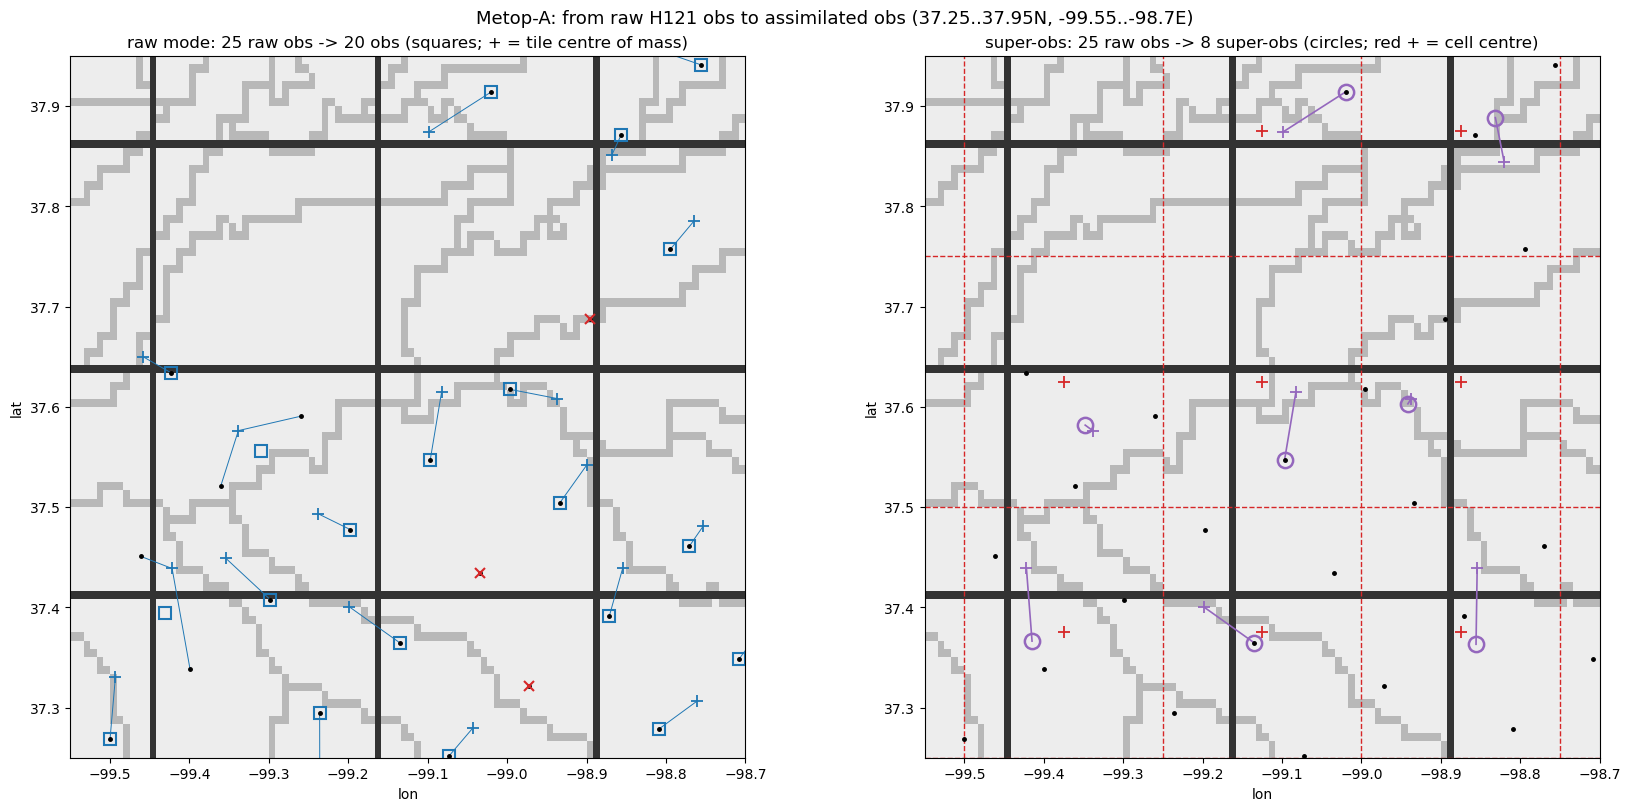

In [8]:
def plot_aggregation(ax, mode, sat=SHOW_SAT):
    tile_background(ax, ZOOM)
    raw = inbox(RAW[RAW.sat == sat], ZOOM)
    good = raw[raw.tile > 0]
    if mode == 'raw':
        agg = inbox(RAWMODE[RAWMODE.sat == sat], ZOOM)
        for _, r in good.iterrows():
            ax.plot([r.lon, COM_LON[r.tile - 1]], [r.lat, COM_LAT[r.tile - 1]], '-', color='tab:blue', lw=0.7)
        ax.plot(COM_LON[agg.tile - 1], COM_LAT[agg.tile - 1], '+', color='tab:blue', ms=8, mew=1.3)
        ax.plot(raw.lon, raw.lat, '.', color='k', ms=5)
        ax.plot(raw.lon[raw.tile < 0], raw.lat[raw.tile < 0], 'x', color='tab:red', ms=7, mew=1.5)
        ax.plot(agg.lon, agg.lat, 's', mfc='none', mec='tab:blue', ms=9, mew=1.5)
        ax.set_title(f'raw mode: {len(raw)} raw obs -> {len(agg)} obs (squares; + = tile centre of mass)')
    else:
        agg = inbox(SO[SO.sat == sat], ZOOM)
        superob_grid_lines(ax, ZOOM, color='tab:red', ls='--', lw=1)
        cells = inbox(SO_ALL[SO_ALL.sat == sat], ZOOM)
        ax.plot(cells.cell_lon0 + SUPEROB_GRID / 2, cells.cell_lat0 + SUPEROB_GRID / 2, '+', color='tab:red', ms=9, mew=1.3)
        for _, r in agg.iterrows():
            ax.plot([r.lon, COM_LON[r.tile - 1]], [r.lat, COM_LAT[r.tile - 1]], '-', color='tab:purple', lw=1.2)
        ax.plot(COM_LON[agg.tile - 1], COM_LAT[agg.tile - 1], '+', color='tab:purple', ms=8, mew=1.3)
        ax.plot(raw.lon, raw.lat, '.', color='k', ms=5)
        ax.plot(agg.lon, agg.lat, 'o', mfc='none', mec='tab:purple', ms=11, mew=1.8)
        ax.set_title(f'super-obs: {len(raw)} raw obs -> {len(agg)} super-obs (circles; red + = cell centre)')
    finish(ax, ZOOM)

fig, axs = plt.subplots(1, 2, figsize=(17, 8), constrained_layout=True)
plot_aggregation(axs[0], 'raw')
plot_aggregation(axs[1], 'superob')
fig.suptitle(f'{SAT_LABEL[SHOW_SAT]}: from raw H121 obs to assimilated obs '
             f'({ZOOM[0]}..{ZOOM[1]}N, {ZOOM[2]}..{ZOOM[3]}E)', fontsize=13)
fig.savefig(FIG_DIR / 'zoom_aggregation.png', dpi=150)
plt.show()

## 5. Check: positions and tiles vs ObsFcstAna

Match the reconstructed obs to each run's ObsFcstAna (2019-05-01 03z) by (satellite, tile) inside the region
and compare positions. Obs that the reader emits but that are later screened out (scaling, QC in
`get_obs_pred`) would appear as "reconstructed only".

In [9]:
def read_ofa(run):
    f = run_file(run, 'ana/ens_avg/Y2019/M05', f'*ObsFcstAna.{ANA_TIME:%Y%m%d_%H}00z.nc4')
    with nc.Dataset(f) as d:
        df = pd.DataFrame({v: np.asarray(d[v][:]) for v in ['species', 'tilenum', 'lat', 'lon', 'obs', 'fcst',
                                                             'fcstvar', 'assim_flag']})
    df = df[df.species.isin(SPECIES_TO_SAT)].copy()
    df['sat'] = df.species.map(SPECIES_TO_SAT)
    return df

OFA = {run: read_ofa(run) for run in RUNS}
REC = {'raw': RAWMODE, 'superob': SO}
MATCH = {}
for run in RUNS:
    rec, ofa = inbox(REC[run], REGION), inbox(OFA[run], REGION)
    m = rec.merge(ofa, left_on=['sat', 'tile'], right_on=['sat', 'tilenum'], how='outer',
                  suffixes=('_rec', '_ofa'), indicator=True)
    both = m[m._merge == 'both'].copy()
    dpos = np.hypot(both.lat_rec - both.lat_ofa, both.lon_rec - both.lon_ofa)
    print(f'{run:8s}: reconstructed {len(rec)}, ObsFcstAna {len(ofa)}, matched {len(both)}, '
          f'reconstructed only {(m._merge == "left_only").sum()}, ObsFcstAna only {(m._merge == "right_only").sum()}; '
          f'max position difference {dpos.max():.1e} deg')
    MATCH[run] = both

raw     : reconstructed 515, ObsFcstAna 515, matched 515, reconstructed only 0, ObsFcstAna only 0; max position difference 3.8e-06 deg
superob : reconstructed 195, ObsFcstAna 195, matched 195, reconstructed only 0, ObsFcstAna only 0; max position difference 0.0e+00 deg


## 6. The field of view used in `get_obs_pred`

For each obs, `get_obs_pred` finds the tiles whose **centre of mass** falls inside an ellipse around the obs
(`get_tile_num_in_ellipse`: normalised distance `(Δlon/r_x)² + (Δlat/r_y)² ≤ 1`, in degrees), and predicts the
obs as the weighted mean of the tiles' SFMC (per ensemble member):

- **Raw mode** (`FOV = 12.5 km`): `r_y = 2 · 12.5 km` in degrees of latitude, `r_x = r_y / cos(lat)`, i.e. a
  **25 km circle**. Weight = `exp(-½ (d / 12.5 km)²) · area`, so the weight is 1 at the obs, 0.61 at 12.5 km and
  0.14 at the 25 km cut-off.
- **Super-ob mode** (`FOV = 0.141°`): `r_x = r_y = 0.141°`, a circle **in degrees** (≈ 15.7 km N-S, 12.4 km E-W
  here), uniform weight · area. Its area equals the 0.25° cell's area.

A tile counts as "in" or "out" as a whole, based only on its centre of mass. That is why the footprints below
are drawn as shaded tiles, not as smooth discs.

In [10]:
_near = np.where((COM_LAT > REGION[0] - 1) & (COM_LAT < REGION[1] + 1) &
                 (COM_LON > REGION[2] - 1) & (COM_LON < REGION[3] + 1))[0]

def fov_radii(lat, run):
    fov, units = FOV[run]
    if units == 'km':
        ry = FAC_SEARCH_FOV_KM * fov * KM2DEG
        return ry / np.cos(np.radians(lat)), ry
    return fov, fov

def fov_tiles(lat, lon, run):
    # tiles (0-based) in the FOV of an obs at (lat, lon) and their normalised weights, as in get_obs_pred
    rx, ry = fov_radii(lat, run)
    nd2 = (COM_LON[_near] - lon)**2 / rx**2 + (COM_LAT[_near] - lat)**2 / ry**2
    k = nd2 <= 1.0
    tiles = _near[k]
    w = AREA[tiles].copy()
    if FOV[run][1] == 'km':                                      # Gaussian distance weights w.r.t. FOV
        w *= np.exp(-0.5 * FAC_SEARCH_FOV_KM**2 * nd2[k])
    return tiles, w / w.sum()

print(f'radii at {np.mean(REGION[:2]):.1f}N:')
for run in RUNS:
    rx, ry = fov_radii(np.mean(REGION[:2]), run)
    print(f'  {run:8s}: r_x = {rx:.4f} deg ({rx / KM2DEG * np.cos(np.radians(np.mean(REGION[:2]))):.1f} km), '
          f'r_y = {ry:.4f} deg ({ry / KM2DEG:.1f} km)')

radii at 37.5N:
  raw     : r_x = 0.2834 deg (25.0 km), r_y = 0.2248 deg (25.0 km)
  superob : r_x = 0.1410 deg (12.4 km), r_y = 0.1410 deg (15.7 km)


### 6a. One obs, two footprints

The same spot in both modes: a super-ob made of at least 3 raw obs (a typical one) near the centre of the zoom
box, and the raw-mode obs in the same 0.25° cell that is nearest to it. Tiles are
shaded by their normalised weight in the prediction; the outline is the search ellipse (and, for raw mode, the
dotted 12.5 km circle where the Gaussian weight drops to 0.61). Black dots = tile centres of mass inside the
footprint, grey dots = outside. "Effective tiles" is 1 / Σ ŵ², the number of equally weighted tiles that would
give the same spread.

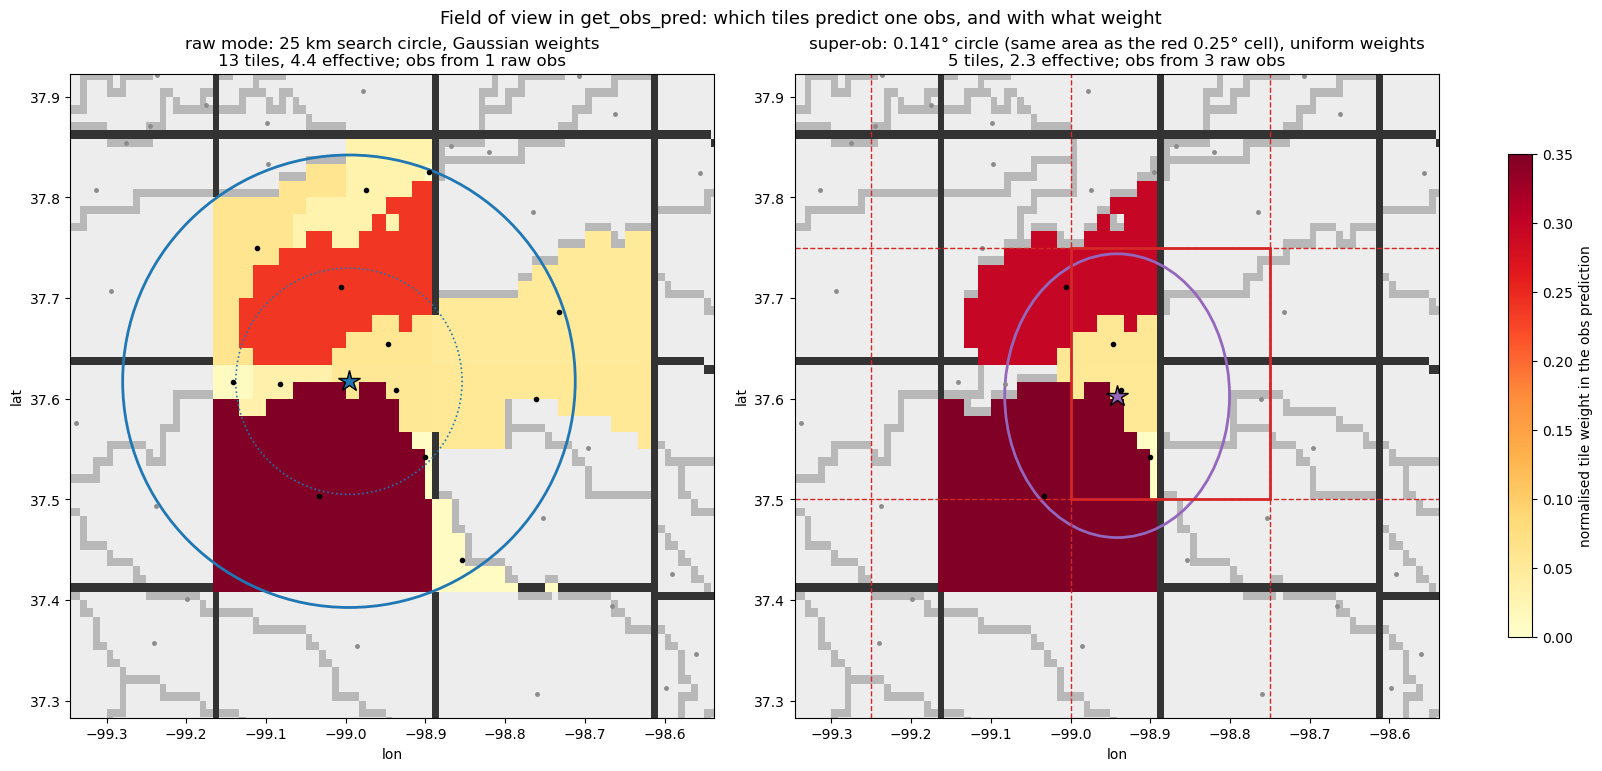

In [11]:
CENTRE = (np.mean(ZOOM[:2]), np.mean(ZOOM[2:]))
so_z = inbox(SO[SO.sat == SHOW_SAT], ZOOM)
so_z = so_z[so_z.n_raw >= 3]                                  # a typical super-ob (about 3 raw obs per cell)
EX_SO = so_z.iloc[np.argmin(np.hypot(so_z.lat - CENTRE[0], so_z.lon - CENTRE[1]))]
rm = RAWMODE[(RAWMODE.sat == SHOW_SAT)]
in_cell = rm[(rm.lat >= EX_SO.cell_lat0) & (rm.lat < EX_SO.cell_lat0 + SUPEROB_GRID) &
             (rm.lon >= EX_SO.cell_lon0) & (rm.lon < EX_SO.cell_lon0 + SUPEROB_GRID)]
EX_RAW = in_cell.iloc[np.argmin(np.hypot(in_cell.lat - EX_SO.lat, in_cell.lon - EX_SO.lon))]
HALF = 0.32
EX_BOX = (EX_SO.lat - HALF, EX_SO.lat + HALF, EX_SO.lon - HALF / np.cos(np.radians(EX_SO.lat)),
          EX_SO.lon + HALF / np.cos(np.radians(EX_SO.lat)))

def draw_footprint(ax, lat, lon, run, color, wmax):
    tile, lat_e, lon_e = tile_background(ax, EX_BOX)
    tiles, w = fov_tiles(lat, lon, run)
    wmap = np.full(tile.shape, np.nan)
    lut = dict(zip(tiles + 1, w))
    for t in np.unique(tile):
        if t in lut:
            wmap[tile == t] = lut[t]
    pm = ax.pcolormesh(lon_e, lat_e, np.ma.masked_invalid(wmap), cmap='YlOrRd', vmin=0, vmax=wmax, rasterized=True)
    rx, ry = fov_radii(lat, run)
    ax.add_patch(Ellipse((lon, lat), 2 * rx, 2 * ry, fill=False, ec=color, lw=2))
    if FOV[run][1] == 'km':
        ax.add_patch(Ellipse((lon, lat), rx, ry, fill=False, ec=color, lw=1.2, ls=':'))
    near = _near[(COM_LAT[_near] > EX_BOX[0]) & (COM_LAT[_near] < EX_BOX[1]) &
                 (COM_LON[_near] > EX_BOX[2]) & (COM_LON[_near] < EX_BOX[3])]
    ins = np.isin(near, tiles)
    ax.plot(COM_LON[near[~ins]], COM_LAT[near[~ins]], '.', color='0.55', ms=5)
    ax.plot(COM_LON[near[ins]], COM_LAT[near[ins]], '.', color='k', ms=6)
    ax.plot(lon, lat, '*', color=color, ms=16, mec='k')
    finish(ax, EX_BOX)
    return pm, tiles, w

fig, axs = plt.subplots(1, 2, figsize=(16, 7.6), constrained_layout=True)
pm, t_raw, w_raw = draw_footprint(axs[0], EX_RAW.lat, EX_RAW.lon, 'raw', 'tab:blue', 0.35)
_, t_so, w_so = draw_footprint(axs[1], EX_SO.lat, EX_SO.lon, 'superob', 'tab:purple', 0.35)
superob_grid_lines(axs[1], EX_BOX, color='tab:red', ls='--', lw=1)
axs[1].add_patch(Rectangle((EX_SO.cell_lon0, EX_SO.cell_lat0), SUPEROB_GRID, SUPEROB_GRID, fill=False,
                           ec='tab:red', lw=2))
axs[0].set_title(f'raw mode: 25 km search circle, Gaussian weights\n{len(t_raw)} tiles, '
                 f'{1 / np.sum(w_raw**2):.1f} effective; obs from {EX_RAW.n_raw:.0f} raw obs')
axs[1].set_title(f'super-ob: 0.141° circle (same area as the red 0.25° cell), uniform weights\n'
                 f'{len(t_so)} tiles, {1 / np.sum(w_so**2):.1f} effective; obs from {EX_SO.n_raw:.0f} raw obs')
fig.colorbar(pm, ax=axs, shrink=0.75, label='normalised tile weight in the obs prediction')
fig.suptitle('Field of view in get_obs_pred: which tiles predict one obs, and with what weight', fontsize=13)
fig.savefig(FIG_DIR / 'fov_single_obs.png', dpi=150)
plt.show()

### 6b. All footprints of one satellite: overlap

Every obs footprint (search ellipse) of one satellite in the zoom box, for both modes. Tiles are coloured by
**how many footprints contain them**. With raw obs, neighbouring obs are only ~12–25 km apart but each
footprint has a 25 km radius, so each tile is inside many footprints and neighbouring obs are predicted from
nearly the same tiles. With super-obs, the footprints roughly tile the plane.

Adding Metop-B and -C would mostly stack identical footprints on top of these (section 4b).

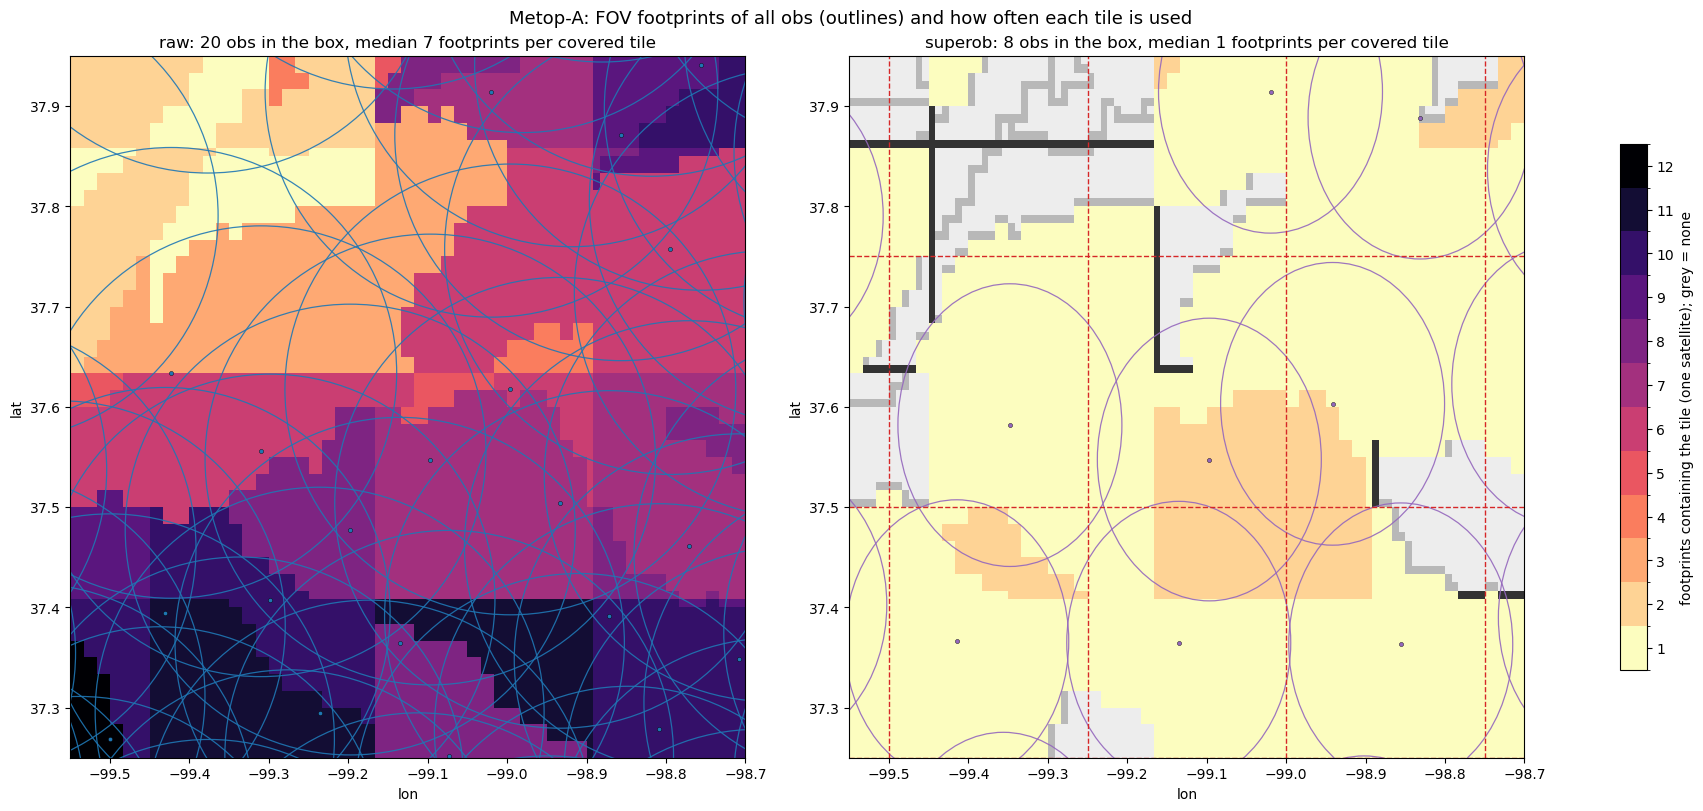

In [12]:
def coverage_count(obs, run, tile_ids):
    count = {}
    for _, r in obs.iterrows():
        for t in fov_tiles(r.lat, r.lon, run)[0]:
            count[t + 1] = count.get(t + 1, 0) + 1
    return np.vectorize(lambda t: count.get(t, 0))(tile_ids)

fig, axs = plt.subplots(1, 2, figsize=(17, 8), constrained_layout=True)
cnorm = mcolors.BoundaryNorm(np.arange(0.5, 13.5), 256)
for ax, run, color in zip(axs, RUNS, ['tab:blue', 'tab:purple']):
    tile, lat_e, lon_e = tile_background(ax, ZOOM)
    obs = inbox(REC[run][REC[run].sat == SHOW_SAT], (ZOOM[0] - 0.3, ZOOM[1] + 0.3, ZOOM[2] - 0.4, ZOOM[3] + 0.4))
    cnt = coverage_count(obs, run, tile).astype(float)
    cnt[tile > N_LAND] = np.nan
    pm = ax.pcolormesh(lon_e, lat_e, np.ma.masked_where(~(cnt > 0), cnt), cmap='magma_r', norm=cnorm, rasterized=True)
    for _, r in obs.iterrows():
        rx, ry = fov_radii(r.lat, run)
        ax.add_patch(Ellipse((r.lon, r.lat), 2 * rx, 2 * ry, fill=False, ec=color, lw=0.9, alpha=0.9))
    ax.plot(obs.lon, obs.lat, '.', color=color, ms=6, mec='k', mew=0.3)
    if run == 'superob':
        superob_grid_lines(ax, ZOOM, color='tab:red', ls='--', lw=1)
    inz = inbox(obs, ZOOM)
    ax.set_title(f'{run}: {len(inz)} obs in the box, median {np.nanmedian(cnt[cnt > 0]):.0f} '
                 f'footprints per covered tile')
    finish(ax, ZOOM)
fig.colorbar(pm, ax=axs, shrink=0.75, ticks=np.arange(1, 13), label='footprints containing the tile (one satellite); grey = none')
fig.suptitle(f'{SAT_LABEL[SHOW_SAT]}: FOV footprints of all obs (outlines) and how often each tile is used',
             fontsize=13)
fig.savefig(FIG_DIR / 'fov_overlap_zoom.png', dpi=150)
plt.show()

### 6c. Check: the FOV rule reproduces the model's prediction

For every matched obs in the region, recompute the prediction from the run's own tile forecast
(`inst3_1d_lndfcstana_Nt`, `SFMC_FCST`, ensemble mean at 03z) with the FOV rule above, and compare with
ObsFcstAna `fcst` (also the ensemble mean). The prediction is linear in the tile values, so the ensemble mean
of the predictions equals the prediction of the ensemble mean.

raw     : max |pred - fcst| = 3.3e-05, median 6.3e-06 m3/m3


superob : max |pred - fcst| = 5.4e-05, median 9.5e-06 m3/m3


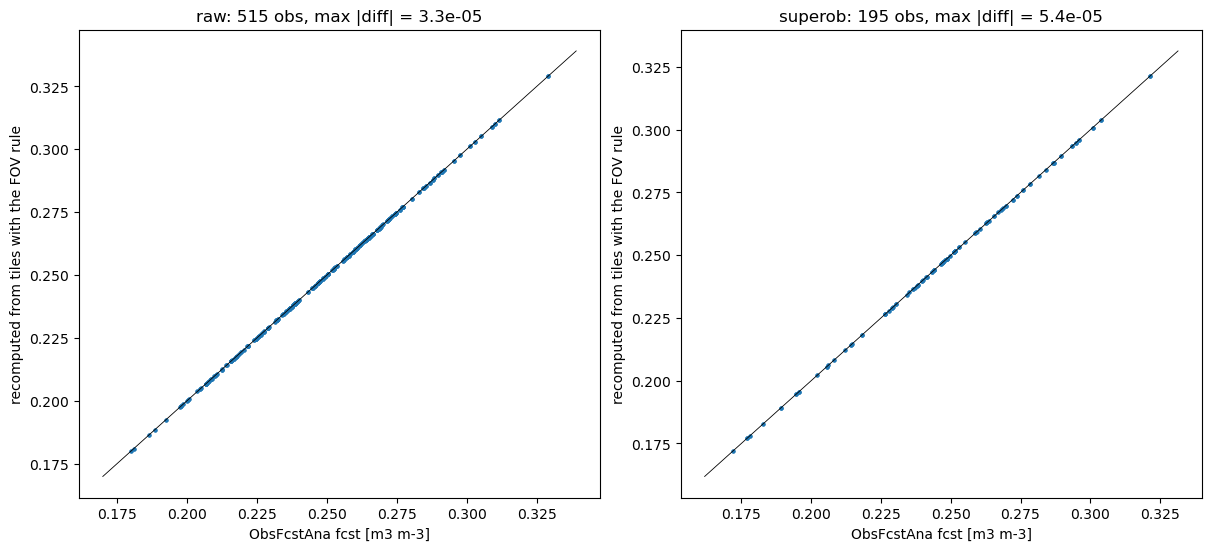

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5.4), constrained_layout=True)
for ax, run in zip(axs, RUNS):
    f = run_file(run, 'cat/ens_avg/Y2019/M05', f'*inst3_1d_lndfcstana_Nt.{ANA_TIME:%Y%m%d_%H}00z.nc4')
    with nc.Dataset(f) as d:
        sfmc = np.asarray(d['SFMC_FCST'][0, :], np.float64)
    b = MATCH[run]
    fov = [fov_tiles(la, lo, run) for la, lo in zip(b.lat_ofa, b.lon_ofa)]
    b['pred'] = [np.sum(w * sfmc[t]) for t, w in fov]
    b['n_fov_tiles'] = [len(t) for t, _ in fov]
    b['n_eff_tiles'] = [1 / np.sum(w**2) for _, w in fov]
    d = (b.pred - b.fcst).abs()
    ax.plot(b.fcst, b.pred, '.', ms=4)
    lim = [b.fcst.min() - 0.01, b.fcst.max() + 0.01]
    ax.plot(lim, lim, 'k-', lw=0.6)
    ax.set_xlabel('ObsFcstAna fcst [m3 m-3]'); ax.set_ylabel('recomputed from tiles with the FOV rule')
    ax.set_title(f'{run}: {len(b)} obs, max |diff| = {d.max():.1e}')
    print(f'{run:8s}: max |pred - fcst| = {d.max():.1e}, median {d.median():.1e} m3/m3')
fig.savefig(FIG_DIR / 'fov_check_vs_ofa.png', dpi=150)
plt.show()

## 7. Raw vs super-obs over the whole region, in numbers

All three satellites, all obs in the 2° × 2.5° region (matched to ObsFcstAna).

- **(a) Tiles per footprint**, effective tiles (1/Σŵ²).
- **(b) Footprints per tile:** how many obs (all satellites) use each tile in their prediction.
- **(c) Footprint similarity vs distance:** for pairs of obs of the **same satellite**, the cosine similarity
  of their tile-weight vectors (1 = the same tiles with the same weights). This is roughly how alike two rows
  of the observation operator H are. Very similar rows add little new information and make the innovation
  covariance HPHᵀ + R harder to invert.
- **(d) Nearest-neighbour distance** between obs of the same satellite, against the obs-error correlation length
  `xcorr` (R is Gaussian in degrees, `exp(-½ (Δlon² + Δlat²) / xcorr²)`, within one species only;
  `assemble_obs_cov`).

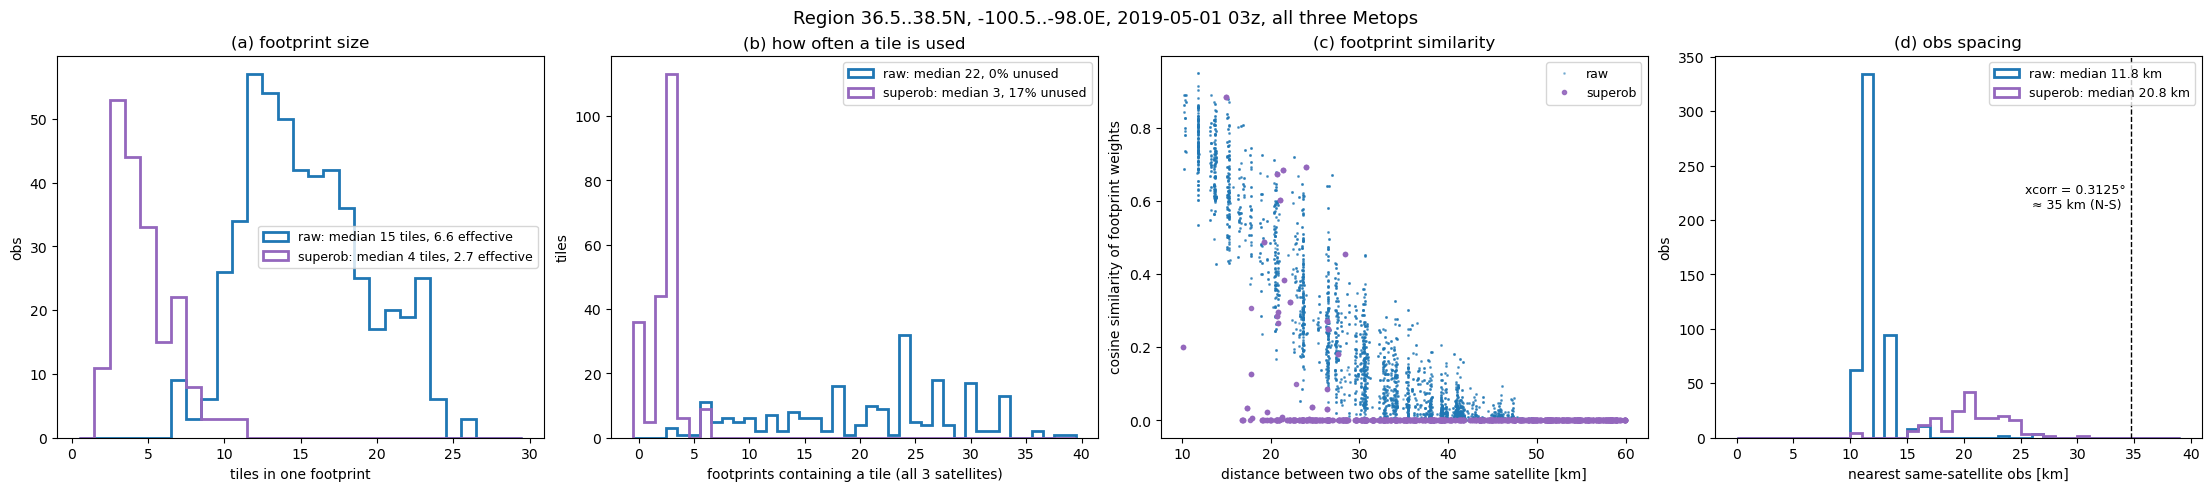

raw     : 515 obs; same-satellite pairs closer than 20 km: 1045, median footprint similarity 0.69
superob : 195 obs; same-satellite pairs closer than 20 km: 37, median footprint similarity 0.00


In [14]:
def weight_vectors(b, run):
    return [dict(zip(*fov_tiles(la, lo, run))) for la, lo in zip(b.lat_ofa, b.lon_ofa)]

pairs = {}
for run in RUNS:
    b = MATCH[run]
    vecs = weight_vectors(b, run)
    rows = []
    for sat in SATS:
        idx = np.where(b.sat.to_numpy() == sat)[0]
        la, lo = b.lat_ofa.to_numpy()[idx], b.lon_ofa.to_numpy()[idx]
        for a in range(len(idx)):
            dkm = np.hypot((lo[a + 1:] - lo[a]) * np.cos(np.radians(la[a])), la[a + 1:] - la[a]) / KM2DEG
            for k in np.where(dkm < 60)[0]:
                va, vb = vecs[idx[a]], vecs[idx[a + 1 + k]]
                dot = sum(w * vb.get(t, 0.0) for t, w in va.items())
                cos = dot / np.sqrt(sum(w * w for w in va.values()) * sum(w * w for w in vb.values()))
                rows.append((dkm[k], cos))
    pairs[run] = np.array(rows)

fig, axs = plt.subplots(1, 4, figsize=(22, 4.8), constrained_layout=True)
colors = {'raw': 'tab:blue', 'superob': 'tab:purple'}
for run in RUNS:
    b = MATCH[run]
    axs[0].hist(b.n_fov_tiles, bins=np.arange(0.5, 30.5), histtype='step', lw=2, color=colors[run],
                label=f'{run}: median {b.n_fov_tiles.median():.0f} tiles, {b.n_eff_tiles.median():.1f} effective')
    use = {}
    for v in weight_vectors(b, run):
        for t in v:
            use[t] = use.get(t, 0) + 1
    tiles_r = np.where((COM_LAT > REGION[0] + 0.3) & (COM_LAT < REGION[1] - 0.3) &
                       (COM_LON > REGION[2] + 0.3) & (COM_LON < REGION[3] - 0.3))[0]   # away from the edges
    n_use = np.array([use.get(t, 0) for t in tiles_r])
    axs[1].hist(n_use, bins=np.arange(-0.5, 40.5), histtype='step', lw=2, color=colors[run],
                label=f'{run}: median {np.median(n_use):.0f}, {np.mean(n_use == 0):.0%} unused')
    p = pairs[run]
    axs[2].plot(p[:, 0], p[:, 1], '.', ms=2 if run == 'raw' else 6, alpha=0.4 if run == 'raw' else 0.9,
                color=colors[run], label=run, zorder=1 if run == 'raw' else 3)
    nn = []
    for sat in SATS:
        s = b[b.sat == sat]
        la, lo = s.lat_ofa.to_numpy(), s.lon_ofa.to_numpy()
        for a in range(len(s)):
            dd = np.hypot((lo - lo[a]) * np.cos(np.radians(la[a])), la - la[a]) / KM2DEG
            dd[a] = np.inf
            nn.append(dd.min())
    axs[3].hist(nn, bins=np.arange(0, 40, 1), histtype='step', lw=2, color=colors[run],
                label=f'{run}: median {np.median(nn):.1f} km')
axs[3].axvline(XCORR / KM2DEG, color='k', ls='--', lw=1)
axs[3].text(XCORR / KM2DEG - 0.5, axs[3].get_ylim()[1] * 0.6, f'xcorr = {XCORR}°\n≈ {XCORR / KM2DEG:.0f} km (N-S) ',
            fontsize=9, ha='right')
axs[0].set_xlabel('tiles in one footprint'); axs[0].set_ylabel('obs')
axs[1].set_xlabel('footprints containing a tile (all 3 satellites)'); axs[1].set_ylabel('tiles')
axs[2].set_xlabel('distance between two obs of the same satellite [km]')
axs[2].set_ylabel('cosine similarity of footprint weights')
axs[3].set_xlabel('nearest same-satellite obs [km]'); axs[3].set_ylabel('obs')
for ax, t in zip(axs, ['(a) footprint size', '(b) how often a tile is used', '(c) footprint similarity',
                       '(d) obs spacing']):
    ax.set_title(t); ax.legend(fontsize=9)
fig.suptitle(f'Region {REGION[0]}..{REGION[1]}N, {REGION[2]}..{REGION[3]}E, {ANA_TIME:%Y-%m-%d %H}z, '
             'all three Metops', fontsize=13)
fig.savefig(FIG_DIR / 'region_fov_statistics.png', dpi=150)
plt.show()

for run in RUNS:
    p = pairs[run]
    close = p[:, 0] < 20
    print(f'{run:8s}: {len(MATCH[run])} obs; same-satellite pairs closer than 20 km: {close.sum()}, '
          f'median footprint similarity {np.median(p[close, 1]) if close.any() else np.nan:.2f}')

### 7a. What that means for R in this box

Condition number of the obs-error correlation matrix R for the obs of each satellite in the region, built as
in `assemble_obs_cov` (computed in double precision here; the EnKF solves `HPHᵀ∘ρ + R` in **single** precision,
where condition numbers approaching 1/ε₃₂ ≈ 10⁷ leave no accurate digits).

In [15]:
rows = []
for run in RUNS:
    b = MATCH[run]
    for sat in SATS:
        s = b[b.sat == sat]
        la, lo = s.lat_ofa.to_numpy(np.float64), s.lon_ofa.to_numpy(np.float64)
        d2 = ((lo[:, None] - lo[None, :])**2 + (la[:, None] - la[None, :])**2) / XCORR**2
        R = np.exp(-0.5 * d2)
        ev = np.linalg.eigvalsh(R)
        rows.append({'run': run, 'sat': sat, 'obs': len(s), 'cond(R)': ev.max() / max(ev.min(), 1e-300),
                     'min eigenvalue': ev.min()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f'{x:.3g}'))
print('\nobs-error correlation between nearest neighbours at the median spacing (N-S distance):')
for run, d_km in [('raw', 11.8), ('superob', 20.8)]:
    print(f'  {run:8s}: {d_km} km -> exp(-0.5 (d/xcorr)^2) = {np.exp(-0.5 * (d_km * KM2DEG / XCORR)**2):.2f}')

    run     sat  obs  cond(R)  min eigenvalue
    raw metop_a  195 4.15e+10        5.66e-10
    raw metop_b  125 1.15e+10        1.87e-09
    raw metop_c  195 4.15e+10        5.66e-10
superob metop_a   73 2.19e+04        0.000375
superob metop_b   49 1.59e+04        0.000496
superob metop_c   73 2.19e+04        0.000375

obs-error correlation between nearest neighbours at the median spacing (N-S distance):
  raw     : 11.8 km -> exp(-0.5 (d/xcorr)^2) = 0.94
  superob : 20.8 km -> exp(-0.5 (d/xcorr)^2) = 0.84


## 8. Summary

Numbers are for Metop-A/B/C in the 2° × 2.5° south-west Kansas box at 2019-05-01 03z (sections 4–7).

**Reproduction.** The Python version reproduces the reader's per-file QC counts, the global super-ob summary
(occupied cells, cells without a tile, collisions, emitted) for all three Metops, every obs position and tile
in the box, and the ObsFcstAna forecast to float precision (≤ 5e-5 m³/m³), in both modes. To get there it had to
copy the reader's single-precision arithmetic and the 64 s window offset (section 3). So the figures show what
GEOSldas actually did.

**Aggregation.** At CF0360 most tiles receive a single raw obs: raw mode averages only ~1.2 raw obs per
assimilated obs, so it keeps almost the full 12.5 km H121 density (median nearest neighbour 11.8 km). Super-obs
average ~3.4 raw obs per 0.25° cell, with a median spacing of 20.8 km. Their positions are not on a regular
grid (mean location), so a few neighbours across cell edges are only ~10 km apart.

**Field of view.** This is where the two modes differ most:

- A raw-mode obs is predicted from a **25 km-radius Gaussian footprint**: median 15 tiles (6.6 effective).
  That footprint is about twice the obs spacing. Same-satellite neighbours 12 km apart share most of their
  weighted tiles (cosine similarity ~0.6–0.9), so their H rows are close to duplicates. Each tile is used by a
  median of **22** obs predictions (all three satellites).
- A super-ob is predicted from a **0.141° uniform footprint** (the cell's area): median 4 tiles
  (2.7 effective). Neighbouring footprints are almost always **disjoint** (similarity 0). Each tile is used by
  a median of 3 obs, and **17 % of the tiles in the box are in no footprint at all** (their centres of mass fall
  between the circles). Those tiles still get increments through the ensemble covariances, but no obs
  predicts them directly.
- The super-ob footprint is **small compared with CF0360 tiles** (catchment pieces of a ~28 km cell). The
  model side of a super-ob therefore often comes from just 1–3 tiles, while the obs side averages ~3 raw obs
  over a whole 0.25° cell. So the obs and its prediction need not represent the same area. (An observation
  from these pictures, not tested: a larger FOV or one matched to the cell would change it.)

**R.** With `xcorr = 0.3125°` (≈ 35 km) the obs-error correlation between nearest neighbours is ~0.94 for raw
obs and ~0.84 for super-obs, and cond(R) per satellite in this box is ~10¹⁰ (raw) vs ~2·10⁴ (super-obs), i.e.
past vs well short of single-precision limits. This is consistent with the conditioning explanation of the
raw-obs blow-up.

**Coincident satellites.** In this window Metop-A, -C and -B passed over the box at about 02:41, 03:21 and
03:54 UTC and observed the same H121 grid points. So up to three obs share an identical footprint (different
values). R treats them as independent (no cross-species correlation), in both modes.

Possible follow-ups (not done here): the same panels for a high-latitude box; a FOV sensitivity test for
super-obs (e.g. footprint = the whole cell); the EASE M36 0.5° collision geometry
(`M21C_testing/sobtest_collision_geometry.py`).